# Bank Marketing Data Analysis
This notebook presents an analysis of the `bankmarketing.csv` dataset, which includes data related to a bank's marketing campaigns. The main goal is to understand customer behavior and predict whether a client will subscribe to a term deposit.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('bankmarketing.csv')

# Display the first few rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [1]:
# Check for missing values and data types
print("Shape:", df.shape)
print()
print("Data Types:")
print(df.dtypes)
print()
print("Missing Values per Column:")
print(df.isnull().sum())
print()
print("No missing values found — dataset is clean!")

Shape: (41188, 21)

Data Types:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Missing Values per Column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0


In [1]:
# Summary statistics
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


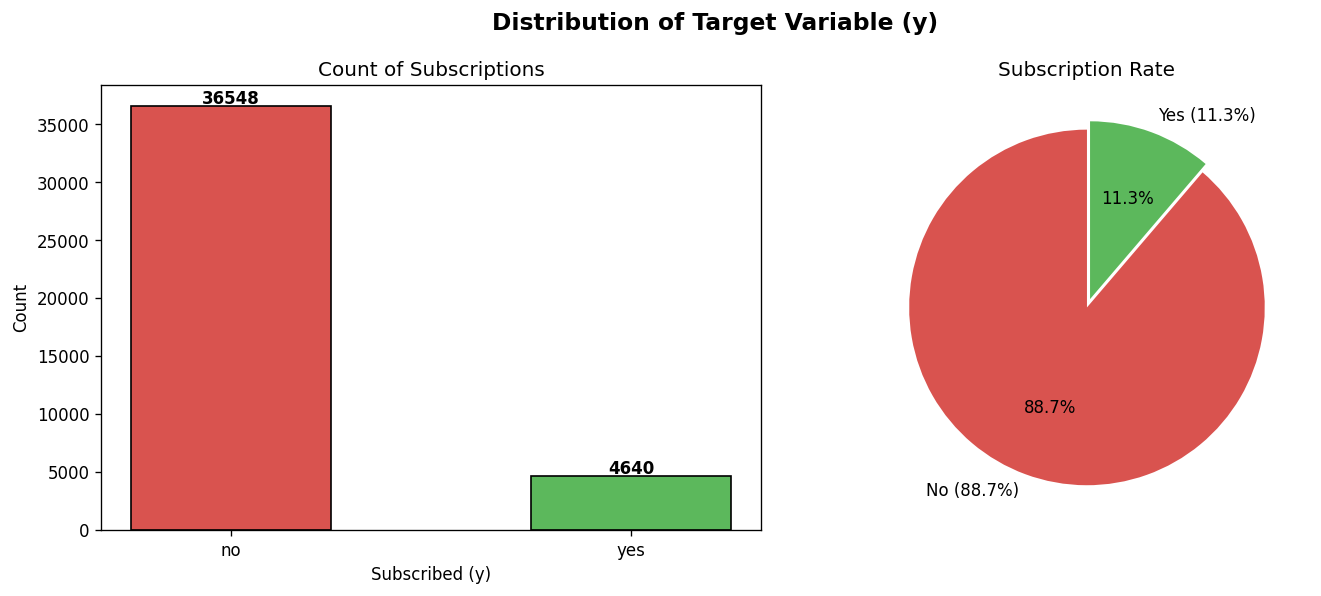

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution of Target Variable (y)', fontsize=14, fontweight='bold')

counts = df['y'].value_counts()
colors = ['#d9534f', '#5cb85c']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Count of Subscriptions')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 200, str(val), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No (88.7%)', 'Yes (11.3%)'],
            colors=colors, autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
axes[1].set_title('Subscription Rate')

plt.tight_layout()
plt.show()

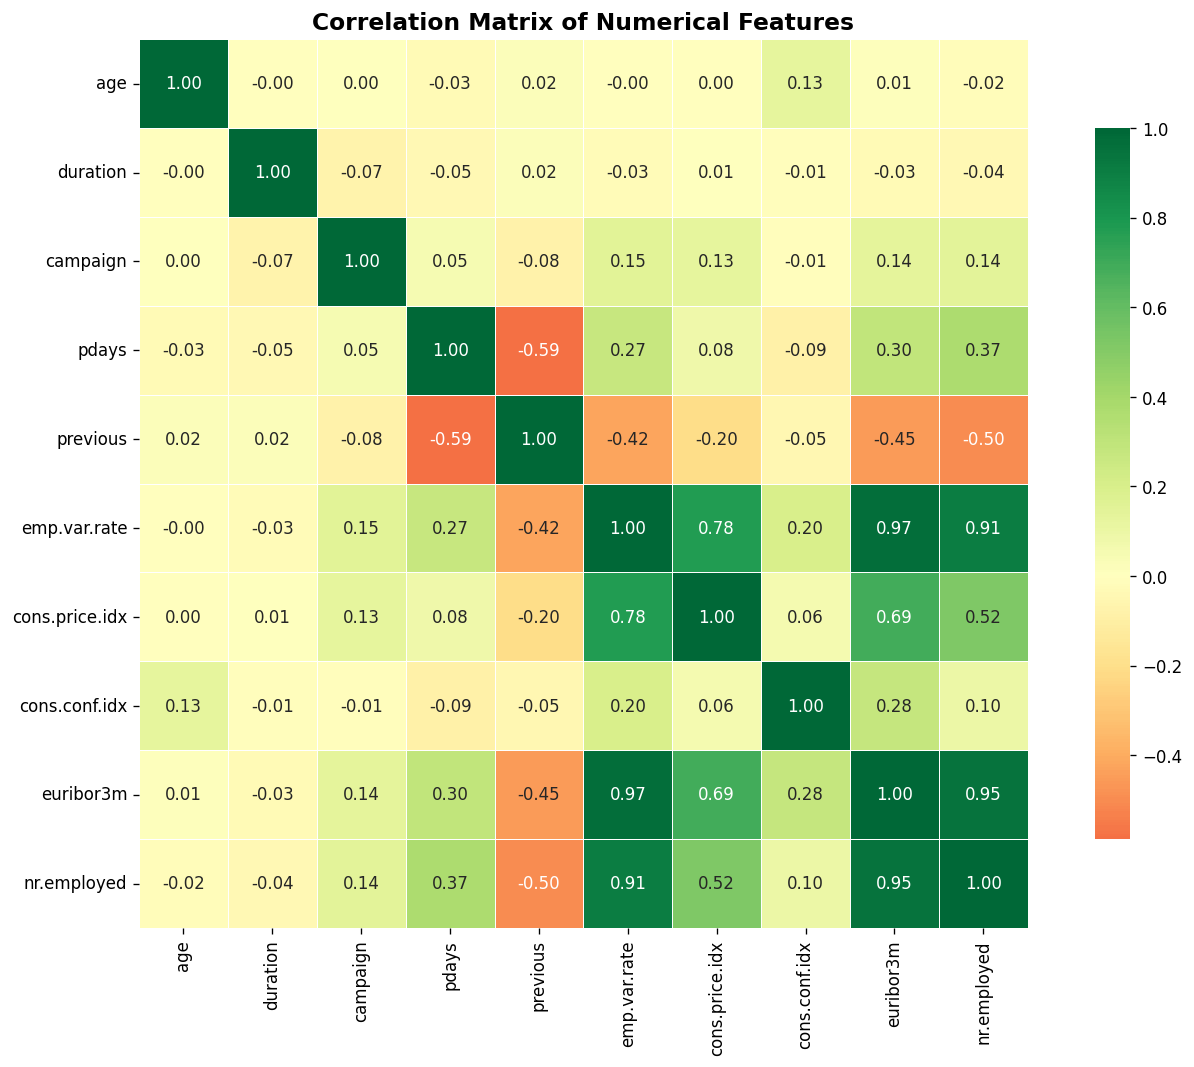

In [1]:
# Correlation matrix for numerical features
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion

In this analysis, we explored the structure and composition of the bank marketing dataset. Key takeaways include:

- **Dataset size:** 41,188 records across 21 features (10 numerical, 10 categorical, 1 target).
- **No missing values** were found — the dataset is clean and ready for modeling.
- **Class imbalance:** ~88.7% of clients did not subscribe (`no`) vs 11.3% who did (`yes`). This imbalance should be addressed in modeling (e.g., SMOTE, class weights).
- **Strong correlations:** `euribor3m`, `emp.var.rate`, and `nr.employed` are highly correlated with each other, suggesting multicollinearity — dimensionality reduction or careful feature selection is advised.
- **Duration matters:** Call `duration` is strongly linked to outcomes but is only known after contact, so it should be excluded from predictive models to avoid data leakage.

This initial inspection sets the foundation for a deeper analysis or machine learning workflow to improve marketing effectiveness.
